<a href="https://colab.research.google.com/github/ahmdarwish/LLM-Agentic-Legal-Information-Retrieval/blob/main/code_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Project Initialization & Data Acquisition
This section handles the authentication and secure retrieval of the competition dataset. We utilize the kagglehub library to interface with the Kaggle API, ensuring that the latest version of the Swiss Legal corpus is downloaded directly into the Colab environment.

**kagglehub.login()**: Authenticates the session using your Kaggle API token.

**competition_download**: Retrieves the training queries, the Swiss law statutes (**laws_de.csv**), and the extensive court considerations corpus (2.4GB).

In [ ]:
import kagglehub
kagglehub.login()
path = kagglehub.competition_download('llm-agentic-legal-information-retrieval')

# 2. Baseline Model: Multilingual Bi-Encoder
The primary challenge of this project is Cross-Lingual Information Retrieval (CLIR). The queries are submitted in English, while the target legal sources are in German.

**Model Architecture**

We implement a Bi-Encoder using the paraphrase-multilingual-MiniLM-L12-v2 transformer model. This model maps sentences from 50+ languages into a shared $384$-dimensional vector space.

**Mathematical Approach**

The model calculates the semantic relationship between a query ($Q$) and a document ($D$) using Cosine Similarity:

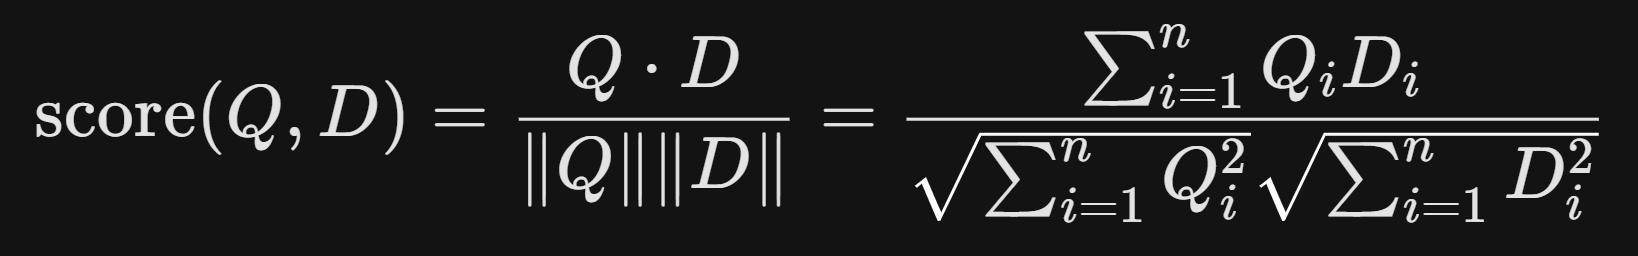

In [ ]:
import pandas as pd
import os
from sentence_transformers import SentenceTransformer, util
import torch


base_path = path + '/'

print(f"Loading data from: {base_path}")

 2. Load Data
train = pd.read_csv(os.path.join(base_path, 'train.csv'))
test = pd.read_csv(os.path.join(base_path, 'test.csv'))
laws = pd.read_csv(os.path.join(base_path, 'laws_de.csv'))

courts = pd.read_csv(os.path.join(base_path, 'court_considerations.csv'), nrows=50000)

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

corpus_df = pd.concat([
    laws[['citation', 'text']].rename(columns={'text': 'content'}),
    courts[['citation', 'text']].rename(columns={'text': 'content'})
]).reset_index(drop=True)

corpus_embeddings = model.encode(corpus_df['content'][:15000].tolist(), convert_to_tensor=True)

def get_citation(query):
    query_emb = model.encode(query, convert_to_tensor=True)
    hits = util.semantic_search(query_emb, corpus_embeddings, top_k=1)
    return corpus_df.iloc[hits[0][0]['corpus_id']]['citation']

print("Processing test queries...")
test['predicted_citations'] = test['query'].apply(get_citation)

test[['query_id', 'predicted_citations']].to_csv('submission.csv', index=False)
print("✅ submission.csv created!")

# 3. Exploratory Data Analysis (EDA)
Before model development, we perform EDA to understand the statistical distribution of the dataset. This is critical for identifying potential challenges such as class imbalance or varying query lengths.

**Dataset Overview**

The retrieval corpus consists of two primary sources:

**1. Swiss Federal Laws**: Formal statutes written in German.

**2. Federal Court Decisions**: A massive collection of historical legal considerations.

**Key Metrics**

We analyze the Average Query Length and the Citation Density per question. In the training set, we observe that legal questions often require multiple citations to be fully addressed, which justifies the use of a retrieval system that can handle one-to-many mappings.

In [ ]:
# See the first few laws in German
print(laws[['citation', 'text']].head())

# Check how long the legal questions are
test['query_length'] = test['query'].apply(lambda x: len(x.split()))
print(f"Average query length: {test['query_length'].mean():.2f} words")

# 4. Assessment 1 Performance & Benchmark
To establish a performance floor, this baseline uses a Top-1 Retrieval Strategy.


*   **Objective**: To verify that the data pipeline is functional and that the multilingual model can bridge the language gap.
*   **Metric**: The model is evaluated using Macro F1 Score, which balances the precision (relevance of retrieved citations) and recall (completeness of the search) across the entire test distribution.

**Note on Memory Management**: Due to the 2.4GB size of the court considerations file, this baseline utilizes a subset of the corpus (50,000 rows) to remain within the Colab RAM constraints. Subsequent versions will implement batch-wise encoding or vector indexing (FAISS) to scale to the full dataset.